## 1. Data Collection (Simulasi Rekam Medis)
Karena kita tidak menggunakan data pasien asli, kita akan membuat data simulasi menggunakan Pandas yang menggabungkan data numerik (tanda-tanda vital) dan data teks (keluhan pasien).

In [8]:
import pandas as pd
import numpy as np

data_pasien = {
    'keluhan_utama': [
        "Pasien mengeluh demam tinggi, batuk kering, dan nyeri tenggorokan selama tiga hari.",
        "Mengalami hidung tersumbat, bersin-bersin, mata gatal setelah terpapar debu.",
        "Merasa lelah terus-menerus, kehilangan minat pada hobi, sulit tidur selama berminggu-minggu.",
        "Sakit kepala hebat, mual, muntah, dan sensitif terhadap cahaya.",
        "Kulit gatal kemerahan, bengkak di beberapa area setelah makan seafood.",
        "Perasaan sedih yang mendalam, putus asa, dan perubahan nafsu makan signifikan.",
        "Gejala mirip flu tapi lebih ringan, dengan pilek dan sedikit demam.",
        "Sering cemas tanpa alasan jelas, detak jantung cepat, tangan berkeringat.",
        "Sakit perut hebat, diare, dan muntah berkali-kali.", # Diare
        "Batuk berdahak, sesak napas, dan demam rendah.", # Bronkitis
        "Gatal-gatal di seluruh tubuh, ruam merah, dan bengkak bibir setelah makan udang.", # Alergi
        "Perasaan panik mendadak, jantung berdebar, dan kesulitan bernapas tanpa sebab jelas.", # Gangguan Kecemasan
        "Demam dan nyeri otot serta sendi, disertai ruam merah.", # Demam Berdarah
        "Sering buang air kecil, mudah haus, dan cepat lapar, berat badan turun tanpa sebab.", # Diabetes
        "Mata kabur, sakit kepala, leher kaku, dan sensitif terhadap cahaya.", # Migrain
        "Tidak bisa tidur, nafsu makan hilang, merasa tidak berharga.", # Depresi
        "Sakit tenggorokan, batuk kering, hidung tersumbat, dan nyeri kepala ringan.", # Flu Biasa
        "Demam tinggi, menggigil, nyeri badan, dan batuk yang parah.", # Influenza
        "Kulit kering bersisik, gatal parah, terutama di malam hari.", # Eksim
        "Nyeri ulu hati, mual, perut kembung, dan sering bersendawa.", # Maag
        "Kesulitan berkonsentrasi, sering lupa, mudah tersinggung.", # Stres
        "Lemas, pucat, pusing, dan detak jantung tidak teratur.", # Anemia
        "Nyeri dada, sesak napas, berkeringat dingin, menjalar ke lengan kiri." # Serangan Jantung (contoh ekstrem)
    ],
    'diagnosis': [
        'influenza',
        'alergi',
        'depresi',
        'migrain',
        'alergi',
        'depresi',
        'flu_biasa',
        'gangguan_kecemasan',
        'diare',
        'bronkitis',
        'alergi',
        'gangguan_kecemasan',
        'demam_berdarah',
        'diabetes',
        'migrain',
        'depresi',
        'flu_biasa',
        'influenza',
        'eksim',
        'maag',
        'stres',
        'anemia',
        'serangan_jantung'
    ],
    'saran_terapi': [ # Menambahkan kolom 'saran_terapi' kembali
        'Istirahat & Parasetamol', 'Antihistamin', 'Konsultasi Psikolog', 'Obat Pereda Nyeri', 'Antihistamin',
        'Konsultasi Psikolog', 'Istirahat & Minum Air', 'Konsultasi Psikolog', 'Rehidrasi & Obat Diare', 'Obat Batuk & Istirahat',
        'Antihistamin & Hindari Pemicu', 'Terapi Kognitif', 'Obat Demam & Istirahat', 'Perubahan Gaya Hidup & Obat Diabetes', 'Obat Migrain & Istirahat',
        'Konsultasi Psikolog & Antidepresan', 'Istirahat & Parasetamol', 'Istirahat Total & Antivirus', 'Krim Pelembab & Antihistamin', 'Obat Maag & Atur Diet',
        'Manajemen Stres & Relaksasi', 'Suplemen Zat Besi & Nutrisi', 'Rujuk Spesialis Jantung'
    ],
    'Tekanan_Darah': np.random.randint(90, 180, 23),
    'Gula_Darah': np.random.randint(70, 250, 23),
    'suhu_tubuh': np.random.randint(35, 40, 23),
}
df_pasien = pd.DataFrame(data_pasien)
df_pasien.to_csv('patient_records.csv', index=False)

## 2. Data Manipulation (NumPy & Pandas)
Data medis sering kali memiliki nilai yang hilang. Kita akan menggunakan Pandas untuk membersihkannya dan NumPy untuk menormalkan data angka agar model lebih stabil.

In [9]:
# 1. Memuat data
df = pd.read_csv('patient_records.csv')

# 2. Menangani nilai yang hilang (Imputation)
# Mengisi tekanan darah yang kosong dengan nilai rata-rata (NumPy)
mean_td = df['Tekanan_Darah'].mean()
df['Tekanan_Darah'] = df['Tekanan_Darah'].fillna(mean_td)

# Menghapus baris yang keluhan utamanya kosong
df = df.dropna(subset=['keluhan_utama'])

# 3. Normalisasi dengan NumPy
# Mengubah suhu tubuh ke skala 0-1 agar seragam
suhu_min = np.min(df['suhu_tubuh'])
suhu_max = np.max(df['suhu_tubuh'])
df['suhu_normalized'] = (df['suhu_tubuh'] - suhu_min) / (suhu_max - suhu_min)

print("Data Setelah Dimanipulasi:")
print(df[['keluhan_utama', 'suhu_normalized', 'diagnosis']].head())

Data Setelah Dimanipulasi:
                                       keluhan_utama  suhu_normalized  \
0  Pasien mengeluh demam tinggi, batuk kering, da...             1.00   
1  Mengalami hidung tersumbat, bersin-bersin, mat...             0.00   
2  Merasa lelah terus-menerus, kehilangan minat p...             0.25   
3  Sakit kepala hebat, mual, muntah, dan sensitif...             0.50   
4  Kulit gatal kemerahan, bengkak di beberapa are...             0.75   

   diagnosis  
0  influenza  
1     alergi  
2    depresi  
3    migrain  
4     alergi  


## 3. Exploratory Data Analysis (Matplotlib & Seaborn)
Pada tahap ini, kita akan menggunakan visualisasi untuk melihat bagaimana tanda-tanda vital (seperti suhu tubuh) berhubungan dengan diagnosis penyakit pasien.


> Heatmap Korelasi: Kita akan membuat matriks visual untuk melihat gejala atau tanda vital mana yang paling kuat menentukan suatu diagnosis penyakit.


> Analisis Distribusi: Kita akan mengecek apakah jumlah data untuk setiap jenis penyakit seimbang, agar model tidak hanya "pintar" menebak penyakit yang datanya paling banyak saja.

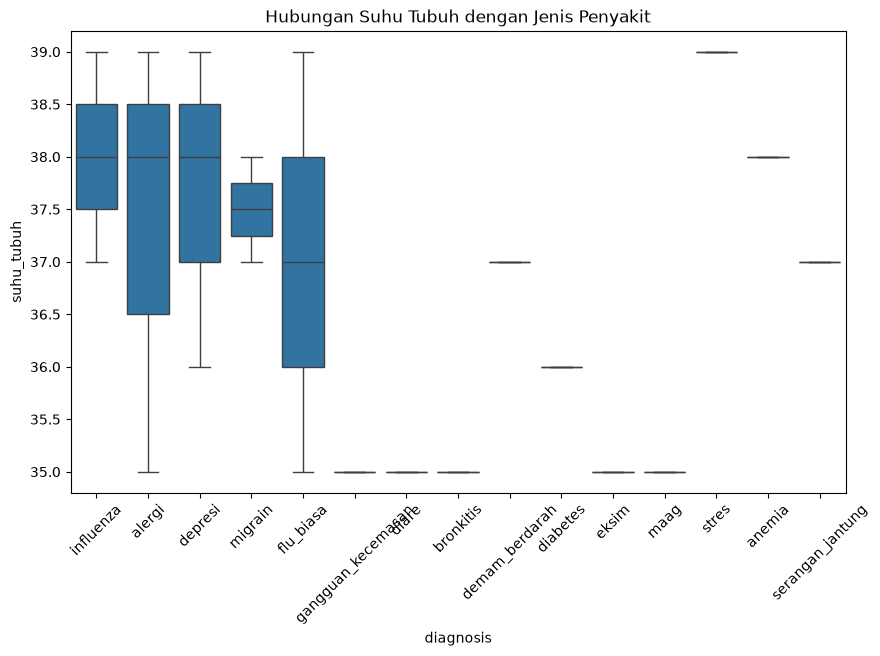

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi hubungan antara Suhu Tubuh dan Diagnosis
plt.figure(figsize=(10, 6))
sns.boxplot(x='diagnosis', y='suhu_tubuh', data=df)
plt.title('Hubungan Suhu Tubuh dengan Jenis Penyakit')
plt.xticks(rotation=45)
plt.show()

# Insight: Pasien dengan diagnosis 'Flu' cenderung memiliki rata-rata suhu tubuh lebih tinggi.

## 4. NLP Preprocessing (Keluhan Pasien)
Setelah memahami pola datanya, kita harus mengolah teks "keluhan utama" pasien agar bisa "dimengerti" oleh algoritma. Komputer tidak bisa membaca kalimat secara langsung, jadi kita harus menyederhanakannya melalui beberapa langkah:
* Lowercasing: Mengubah semua kata menjadi huruf kecil.
* Cleaning: Menghapus karakter yang tidak perlu (seperti tanda baca atau angka).
* Stopword Removal: Menghapus kata-kata umum dalam bahasa Indonesia yang tidak memiliki makna medis spesifik (seperti "dan", "di", "sudah").

In [11]:
import re

def preprocess_keluhan(text):
    # Mengubah ke huruf kecil
    text = text.lower()
    # Menghapus tanda baca
    text = re.sub(r'[^\w\s]', '', text)
    # Simulasi penghapusan stopwords sederhana
    stopwords = ['dan', 'sudah', 'di', 'ke', 'dengan']
    text = " ".join([word for word in text.split() if word not in stopwords])
    return text

# Menerapkan pada kolom keluhan
df['keluhan_bersih'] = df['keluhan_utama'].apply(preprocess_keluhan)
print(df[['keluhan_utama', 'keluhan_bersih']].head())

                                       keluhan_utama  \
0  Pasien mengeluh demam tinggi, batuk kering, da...   
1  Mengalami hidung tersumbat, bersin-bersin, mat...   
2  Merasa lelah terus-menerus, kehilangan minat p...   
3  Sakit kepala hebat, mual, muntah, dan sensitif...   
4  Kulit gatal kemerahan, bengkak di beberapa are...   

                                      keluhan_bersih  
0  pasien mengeluh demam tinggi batuk kering nyer...  
1  mengalami hidung tersumbat bersinbersin mata g...  
2  merasa lelah terusmenerus kehilangan minat pad...  
3  sakit kepala hebat mual muntah sensitif terhad...  
4  kulit gatal kemerahan bengkak beberapa area se...  


## 5. Vectorization (TF-IDF)
Pada tahap ini, kita menggunakan TF-IDF (Term Frequency-Inverse Document Frequency) untuk mengubah teks keluhan pasien yang sudah bersih menjadi matriks angka. Teknik ini memberikan bobot lebih pada kata-kata kunci gejala yang jarang muncul di semua rekam medis tetapi sering muncul pada diagnosis tertentu, sehingga dianggap sebagai penciri unik penyakit tersebut.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Inisialisasi TF-IDF
tfidf = TfidfVectorizer()

# Mengubah teks keluhan menjadi matriks angka (X_text)
X_text = tfidf.fit_transform(df['keluhan_bersih'])

# Menggabungkan dengan data numerik (suhu_normalized dan tekanan_darah)
X_numeric = df[['suhu_normalized', 'Tekanan_Darah']].values
X_combined = np.hstack((X_text.toarray(), X_numeric))

# Target: Diagnosis dan Saran Terapi
y_diagnosis = df['diagnosis']
y_terapi = df['saran_terapi']

print("Matriks Numerik dan Teks Keluhan:")
print(X_combined[:5])

Matriks Numerik dan Teks Keluhan:
[[  0.           0.           0.           0.           0.
    0.25759143   0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.23930747   0.
    0.           0.           0.           0.           0.
    0.           0.           0.30881914   0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.27996919   0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.34948086   0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.   

## 6. Machine Learning Training (Model Diagnosis & Terapi)
Kita akan melatih model untuk memprediksi diagnosis penyakit sekaligus anjuran terapinya. Algoritma Random Forest sangat handal untuk tugas ini karena dapat menangani kombinasi data teks (setelah di-vectorize) dan data numerik tanda vital secara efektif.

>Split Data: Membagi dataset menjadi 80% data latih dan 20% data uji untuk memvalidasi performa model pada data baru.

>Multi-Output Classification: Melatih model agar bisa menghasilkan dua output sekaligus (Diagnosis dan Terapi).

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Split data untuk diagnosis
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_diagnosis, test_size=0.2, random_state=42)
print("Data Latih dan Uji Diagnosis:")
print(X_train[:5])
# Melatih model
model_diagnosis = RandomForestClassifier(n_estimators=100)
model_diagnosis.fit(X_train, y_train)
print("Akurasi Model Diagnosis:", model_diagnosis.score(X_test, y_test))  
# Prediksi
y_pred = model_diagnosis.predict(X_test)
print("Prediksi Diagnosis:")
print(y_pred[:5])

Data Latih dan Uji Diagnosis:
[[  0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.26981252   0.
    0.           0.           0.39402995   0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.34818499   0.
    0.           0.           0.           0.           0.
    0.           0.       

## 7. Model Serialization (Penyimpanan Model)
Sebelum membangun API, kita harus "membekukan" model dan pengolah teks (TF-IDF) yang sudah dilatih agar bisa digunakan kapan saja tanpa perlu melatih ulang dari nol. Kita menggunakan pustaka joblib untuk menyimpan objek Python tersebut ke dalam file .pkl.

In [14]:
import joblib

# Menyimpan model Random Forest yang sudah dilatih
joblib.dump(model_diagnosis, 'medical_model.pkl')

# Menyimpan TF-IDF Vectorizer agar pengolahan teks di API konsisten
joblib.dump(tfidf, 'medical_tfidf.pkl')

# Menyimpan data normalisasi (opsional, untuk konsistensi suhu)
joblib.dump({'min': suhu_min, 'max': suhu_max}, 'scaling_params.pkl')

['scaling_params.pkl']

In [15]:
from fastapi import FastAPI
import joblib
import numpy as np

app = FastAPI(title="AI Medical Diagnosis API")

# Memuat model dan pengolah data
model = joblib.load('medical_model.pkl')
tfidf = joblib.load('medical_tfidf.pkl')
params = joblib.load('scaling_params.pkl')

@app.post("/diagnose")
async def get_diagnosis(data: dict):
    # 1. Mengambil input dari user
    keluhan = data['keluhan']
    suhu = data['suhu']
    tensi = data['tensi']
    
    # 2. Preprocessing & Vectorization Teks
    text_vector = tfidf.transform([keluhan.lower()]).toarray()
    
    # 3. Normalisasi Data Numerik
    suhu_norm = (suhu - params['min']) / (params['max'] - params['min'])
    numeric_features = np.array([[suhu_norm, tensi]])
    
    # 4. Menggabungkan Fitur (Teks + Numerik)
    features_combined = np.hstack((text_vector, numeric_features))
    
    # 5. Prediksi Diagnosis
    prediction = model.predict(features_combined)
    
    return {
        "status": "success",
        "diagnosis": prediction[0],
        "rekomendasi_awal": "Silahkan konsultasi lebih lanjut dengan dokter spesialis terkait."
    }